# Projet Machine Learning — Analyse exploratoire des données
### INSA Toulouse — 4MA — 2025/2026

**Groupe :** Raclot Ai-Vân ; Soulié--Navarro Claire, Portapia Astrid, Masson, Loys

---

Ce notebook présente l'analyse exploratoire du jeu de données *Cardiovascular Disease Risk Prediction Dataset* (Kaggle, 15 000 patients synthétiques, 19 variables). L'objectif est de mieux comprendre la structure des données avant la phase de modélisation, en particulier pour la prédiction de  et de .

In [27]:
# Lecture des données
library(ggplot2)
library(GGally)  #Pour ggpairs
library(corrplot)  #Pour ellipses de corrélation
library(FactoMineR)  #Pour ACP
library(factoextra)
library(reshape2)
library(tidyverse)
library(caret)
library(randomForest)
library(gbm)
library(e1071)
library(rpart)
library(rpart.plot)
library(nnet)
library(glmnet)
library(pROC)
library(gridExtra)

set.seed(42)
cat("Packages chargés avec succès\n")

Packages chargés avec succès


In [28]:
# Chargement du fichier CSV
df <- read.csv("healthcare_synthetic_data.csv", stringsAsFactors = FALSE)
cat("Dimensions :", nrow(df), "lignes x", ncol(df), "colonnes\n")
head(df)

Dimensions : 15000 lignes x 19 colonnes


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


In [29]:
# Valeurs manquantes
cat("=== Valeurs manquantes par variable ===\n")
colSums(is.na(df))

=== Valeurs manquantes par variable ===


Patient_ID                     Age                  Gender 
                      0                       0                       0 
              Height_cm               Weight_kg                     BMI 
                      0                       0                       0 
            Systolic_BP            Diastolic_BP       Cholesterol_Total 
                      0                       0                       0 
        Cholesterol_LDL         Cholesterol_HDL     Fasting_Blood_Sugar 
                      0                       0                       0 
         Smoking_Status     Alcohol_Consumption Physical_Activity_Level 
                      0                       0                       0 
         Family_History            Stress_Level             Sleep_Hours 
                      0                       0                       0 
     Heart_Disease_Risk 
                      0

Le jeu de données ne contient aucune valeur manquante, nous pouvons donc procéder directement à l'analyse.

In [30]:
# Suppression de l'identifiant non informatif
df <- df %>% select(-Patient_ID)

# Variables qualitatives -> facteurs
qual_vars <- c("Gender","Smoking_Status","Alcohol_Consumption",
               "Physical_Activity_Level","Family_History","Heart_Disease_Risk")
for (v in qual_vars) {
  df[[v]] <- as.factor(df[[v]])
}

# Vérification
str(df)

'data.frame':	15000 obs. of  18 variables:
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 2 1 1 1 1 2 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 2 1 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 2 1 1 2 1 1 ...
 $ Phy

## 1. Analyse des variables quantitatives

Nous commençons par définir les types de variables. Personal_ID est supprimé car il s'agit d'un simple identifiant sans valeur prédictive. Les six variables catégorielles (Gender, Smoking_Status, Alcohol_Consumption, Physical_Activity_Level, Family_History, Heart_Disease_Risk) sont converties en facteurs.

Sleep_Hours et Stress_Level sont conservées comme variables quantitatives discrètes : les traiter comme des facteurs multiplierait inutilement le nombre de paramètres dans les modèles.

In [31]:
# Variables quantitatives
quant_vars <- c("Age","Height_cm","Weight_kg","BMI","Systolic_BP","Diastolic_BP",
                "Cholesterol_Total","Cholesterol_LDL","Cholesterol_HDL",
                "Fasting_Blood_Sugar","Stress_Level","Sleep_Hours")

# Statistiques descriptives
df_quant <- df[, quant_vars]
t(apply(df_quant, 2, function(x) c(
  Min=min(x), Mediane=median(x),
  Moyenne=mean(x), Max=max(x), Ecart_type=sd(x)
))) %>% round(2)

,Min,Mediane,Moyenne,Max,Ecart_type
Age,25.0,55.0,54.54,85.0,11.88
Height_cm,138.5,164.7,165.34,198.1,9.19
Weight_kg,33.7,73.9,75.25,150.1,14.11
BMI,14.5,27.2,27.45,46.1,4.13
Systolic_BP,90.0,135.0,135.12,182.0,11.26
Diastolic_BP,60.0,91.0,90.54,120.0,8.44
Cholesterol_Total,127.0,216.0,216.25,303.0,22.69
Cholesterol_LDL,70.0,140.0,140.36,210.0,17.91
Cholesterol_HDL,20.0,43.0,43.31,68.0,5.96
Fasting_Blood_Sugar,60.0,99.0,99.67,167.0,15.26


Le tableau ci-dessus présente les statistiques descriptives des 12 variables quantitatives. On note que les variables sont toutes dans des plages de valeurs médicalement cohérentes (ex. BMI entre 14.5 et 46.1, pression systolique entre 90 et 182 mmHg). 

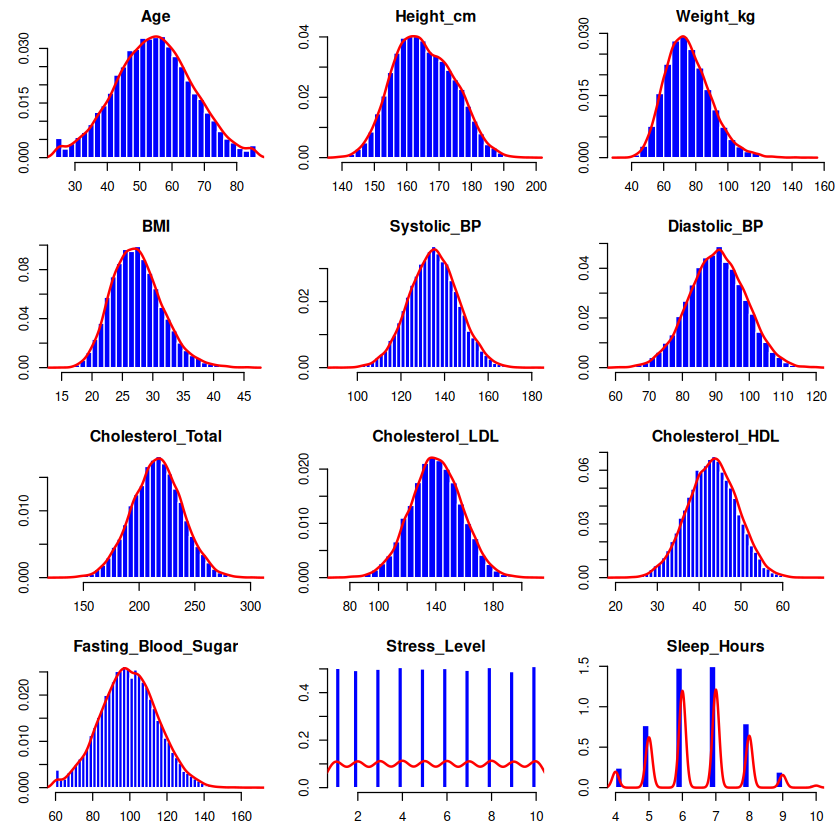

In [32]:
# Histogrammes des variables quantitatives
par(mfrow=c(4,3), mar=c(3,3,2,1))
for (v in quant_vars) {
  hist(df[[v]], main=v, xlab="", col="blue", border="white",
       breaks=40, probability=TRUE)
  lines(density(df[[v]]), col="red", lwd=2)
}

Les histogrammes révèlent plusieurs déviations à la normalité. Sleep_Hours et Stress_Level présentent des distributions clairement discrètes (en marches d'escalier), ce qui est attendu. Height_cm et Weight_kg montrent une légère asymétrie, tandis que Cholesterol_LDL et BMI s'écartent aussi modérément d'une loi normale. Les autres variables (Age, Systolic_BP, Diastolic_BP, Cholesterol_Total, Cholesterol_HDL, Fasting_Blood_Sugar) semblent relativement symétriques.

In [33]:
# Test de normalité (Shapiro-Wilk, sous-échantillon n=500)
cat("=== Tests de Shapiro-Wilk (H0 : normalité) ===\n")
set.seed(42)
idx <- sample(nrow(df), 500)  #Pour ne pas avoir un test trop sensible
for (v in quant_vars) {
  sw <- shapiro.test(df[[v]][idx])
  cat(sprintf("  %-30s W=%.3f, p=%.4f  → %s\n",
              v, sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))
}

=== Tests de Shapiro-Wilk (H0 : normalité) ===
  Age                            W=0.995, p=0.1275  → Normale
  Height_cm                      W=0.991, p=0.0050  → Non normale
  Weight_kg                      W=0.969, p=0.0000  → Non normale
  BMI                            W=0.981, p=0.0000  → Non normale
  Systolic_BP                    W=0.996, p=0.2882  → Normale
  Diastolic_BP                   W=0.996, p=0.2433  → Normale
  Cholesterol_Total              W=0.997, p=0.5772  → Normale
  Cholesterol_LDL                W=0.994, p=0.0389  → Non normale
  Cholesterol_HDL                W=0.995, p=0.1528  → Normale
  Fasting_Blood_Sugar            W=0.996, p=0.2451  → Normale
  Stress_Level                   W=0.934, p=0.0000  → Non normale
  Sleep_Hours                    W=0.936, p=0.0000  → Non normale


Les tests de Shapiro-Wilk (réalisés sur un sous-échantillon de 500 observations pour éviter une sensibilité excessive liée à la grande taille du jeu de données) confirment les observations visuelles : Sleep_Hours, Stress_Level, Height_cm, Weight_kg, Cholesterol_LDL et BMI ne suivent pas une loi normale (p-valeur < 0.05). Les six autres variables ne rejettent pas l'hypothèse de normalité au seuil 5%.

Nous tentons une transformation racine carrée sur les quatre premières afin de nous rapprocher de la normalité.

Weight_kg W=0.993, p=0.0299  → Non normale


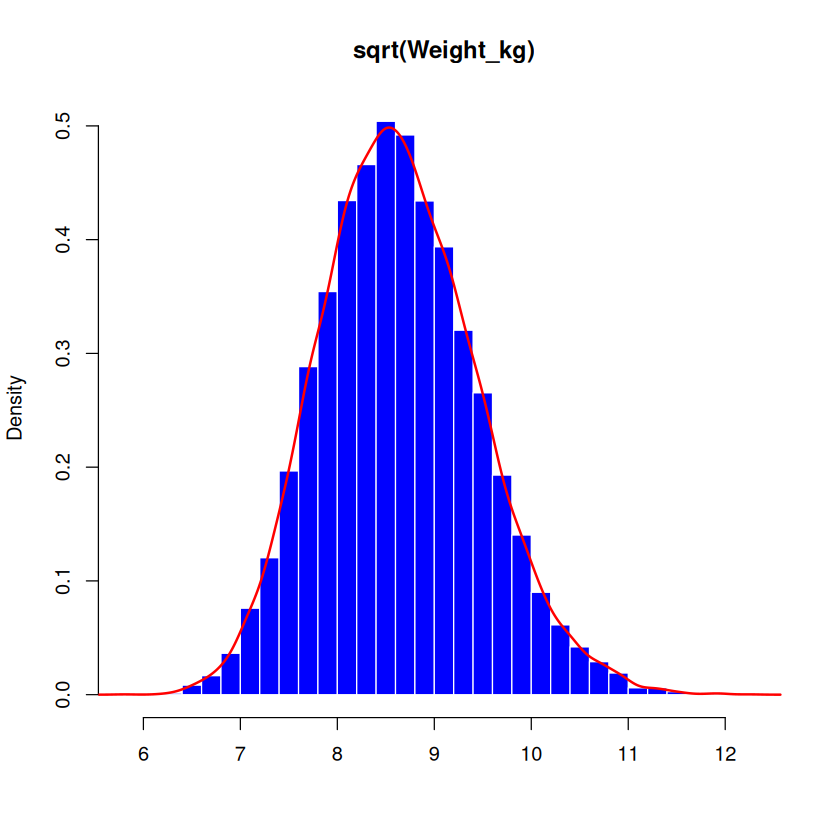

In [34]:
#Transformation de Weight_kg en sqrt(Weight_kg)
hist(sqrt(df[["Weight_kg"]]), 
     main="sqrt(Weight_kg)", 
     xlab="", 
     col="blue", 
     border="white",
     breaks=40, 
     probability=TRUE)

lines(density(sqrt(df[["Weight_kg"]])), col="red", lwd=2)

idx <- sample(nrow(df), 500)
sw <- shapiro.test(df[["Weight_kg"]][idx])
cat(sprintf("Weight_kg W=%.3f, p=%.4f  → %s\n",
              sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))

Height_cm W=0.993, p=0.0225  → Non normale


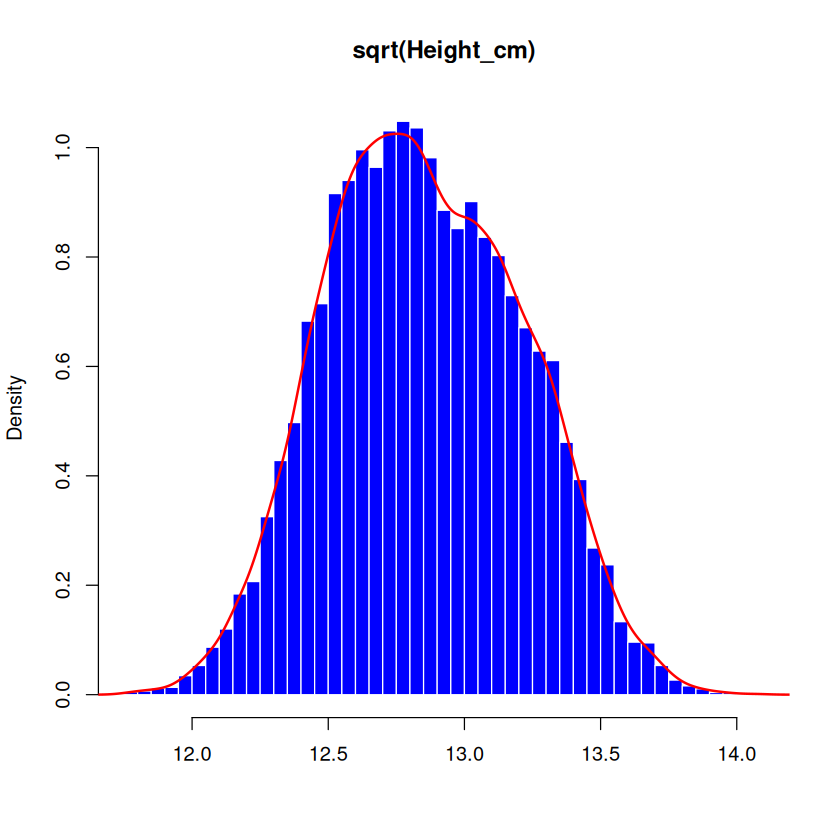

In [35]:
#Transformation de Height_cm en sqrt(Height_cm)
hist(sqrt(df[["Height_cm"]]), 
     main="sqrt(Height_cm)", 
     xlab="", 
     col="blue", 
     border="white",
     breaks=40, 
     probability=TRUE)

lines(density(sqrt(df[["Height_cm"]])), col="red", lwd=2)

idx <- sample(nrow(df), 500)
sw <- shapiro.test(df[["Height_cm"]][idx])
cat(sprintf("Height_cm W=%.3f, p=%.4f  → %s\n",
              sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))

Weight_kg W=0.983, p=0.0000  → Non normale


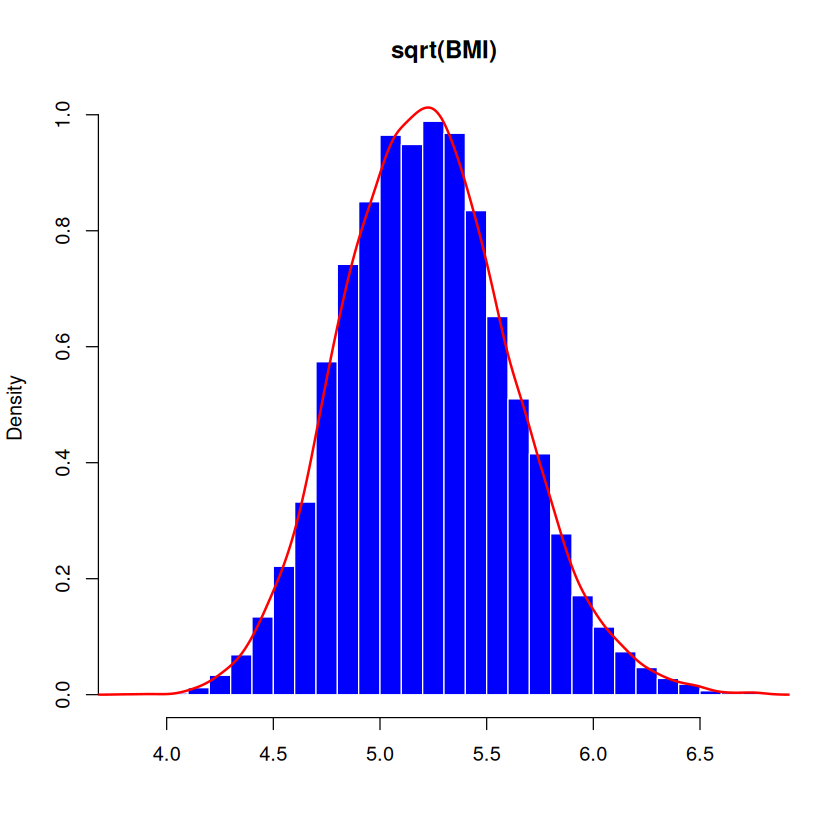

In [36]:
#Transformation de BMI en sqrt(BMI)
hist(sqrt(df[["BMI"]]), 
     main="sqrt(BMI)", 
     xlab="", 
     col="blue", 
     border="white",
     breaks=40, 
     probability=TRUE)

lines(density(sqrt(df[["BMI"]])), col="red", lwd=2)

idx <- sample(nrow(df), 500)
sw <- shapiro.test(df[["BMI"]][idx])
cat(sprintf("Weight_kg W=%.3f, p=%.4f  → %s\n",
              sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))

Weight_kg W=0.994, p=0.0350  → Non normale


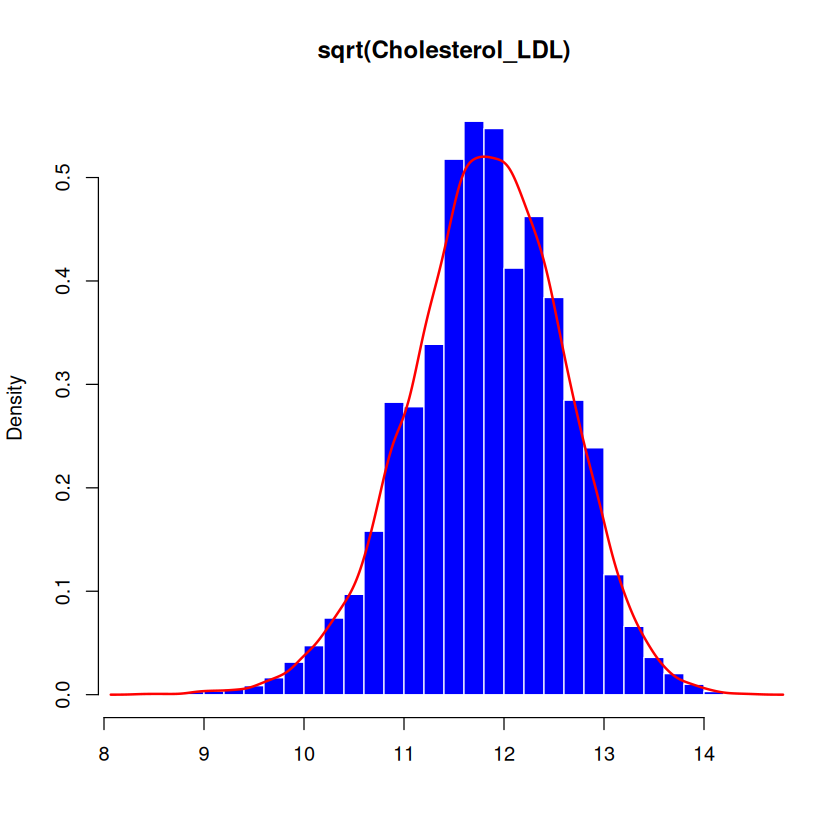

In [37]:
#Transformation de Cholesterol_LDL en sqrt(Cholesterol_LDL)
hist(sqrt(df[["Cholesterol_LDL"]]), 
     main="sqrt(Cholesterol_LDL)", 
     xlab="", 
     col="blue", 
     border="white",
     breaks=40, 
     probability=TRUE)

lines(density(sqrt(df[["Cholesterol_LDL"]])), col="red", lwd=2)

idx <- sample(nrow(df), 500)
sw <- shapiro.test(df[["Cholesterol_LDL"]][idx])
cat(sprintf("Weight_kg W=%.3f, p=%.4f  → %s\n",
              sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))

Aucune transformation ne permet d'obtenir une distribution normale après transformation racine carrée. Cependant, leurs distributions originales restent relativement symétriques, ce qui limite l'impact de la non-normalité pour la plupart des méthodes utilisées en modélisation. Nous décidons donc de conserver les variables originales sans transformation dans la suite du projet.

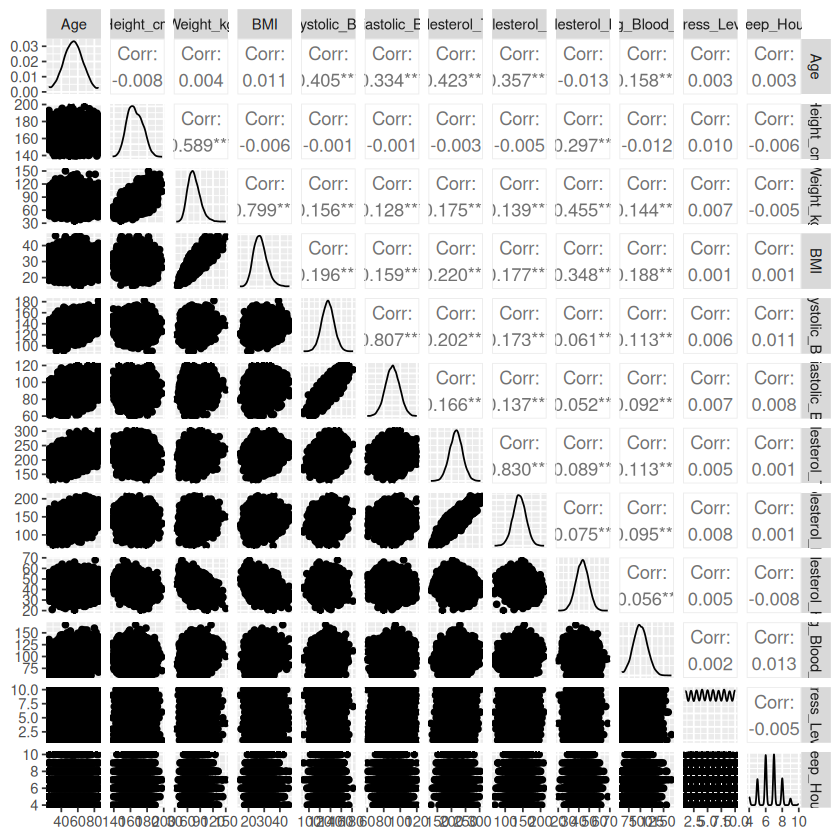

In [38]:
#Plot et corrélation des variables quantitatives 2 à 2
ggpairs(df[, c(1, 3:11, 16:17)])

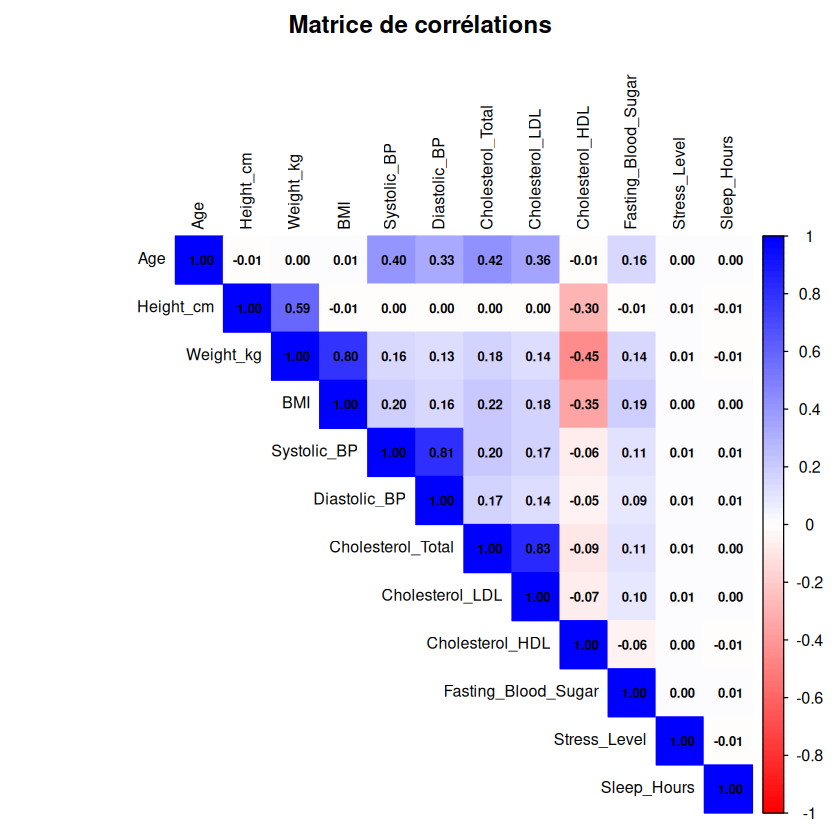

In [39]:
# Matrice de corrélations
corr_mat <- cor(df_quant)
corrplot(corr_mat, method="color", type="upper",
         addCoef.col="black", number.cex=0.65,
         tl.cex=0.8, tl.col="black",
         col=colorRampPalette(c("red","white","blue"))(100),
         title="Matrice de corrélations", mar=c(0,0,2,0))

#Dire quelles corrélations sortent du lot

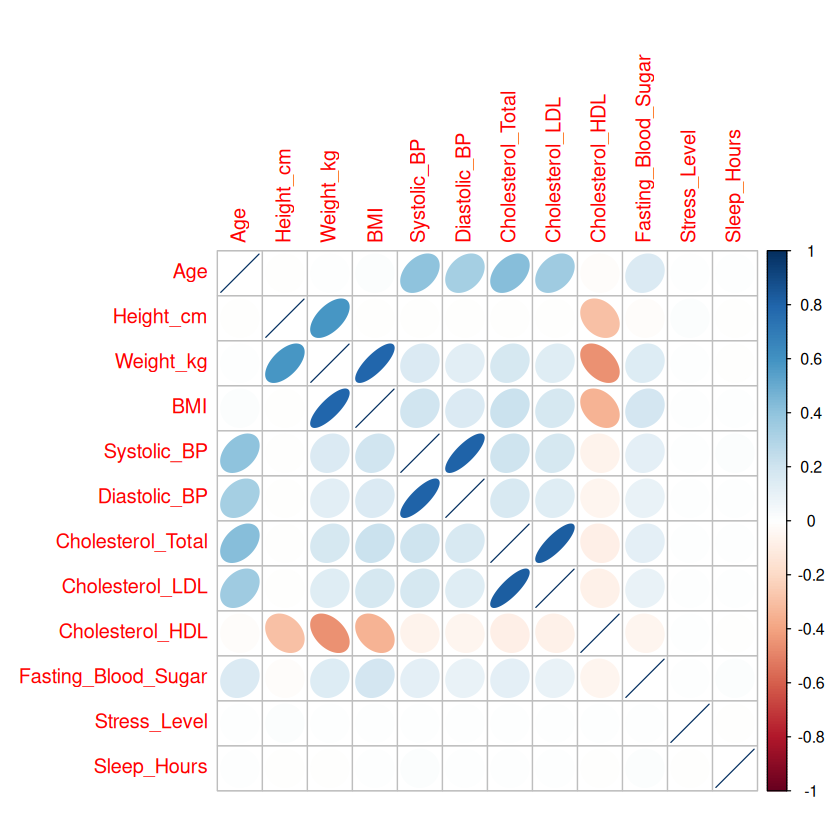

In [40]:
#Ellipses de corrélation
corrplot(cor(df[, c(1, 3:11, 16:17)]),method="ellipse")

L'analyse des matrices de corrélations (numérique, colorée et par ellipses) met en évidence plusieurs relations notables entre variables quantitatives :

**Corrélations positives notables :**
- BMI et Weight_kg (cohérent, le BMI étant calculé à partir du poids)
- Diastolic_BP et Systolic_BP (les deux composantes de la pression artérielle évoluent ensemble)
- Cholesterol_LDL et Cholesterol_total (le LDL est la fraction dominante du cholestérol total)
- Age corrélé positivement avec Systolic_BP, Diastolic_BP, Cholesterol_LDL et Cholesterol_Total
- Weight_kg et Height_cm

**Corrélations négatives :**
- Cholesterol_HDL avec Weight_kg, Cholesterol_HDL et Height_cm : le « bon » cholestérol tend à être plus faible chez les personnes en surpoids, conformément à la littérature médicale.

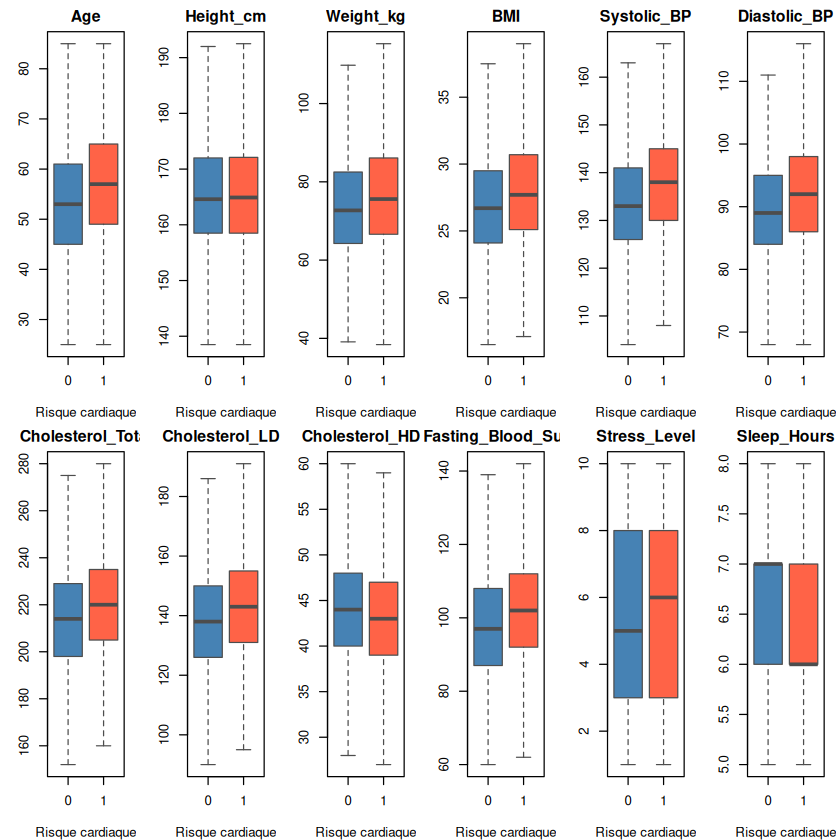

In [41]:
# Boxplots des variables quantitatives selon Heart_Disease_Risk
par(mfrow=c(2,6), mar=c(4,3,2,1))
for (v in quant_vars) {
  boxplot(df[[v]] ~ df$Heart_Disease_Risk,
          main=v, xlab="Risque cardiaque", ylab=v,
          col=c("steelblue","tomato"), border="gray30", outline=FALSE)
}

Les boîtes à moustaches permettent de visualiser l'effet de chaque variable quantitative sur le risque cardiaque ( = 0 : faible risque, 1 : risque élevé).

Height_cm est la seule variable qui ne montre aucune différence entre les deux groupes : la distribution est identique, ce qui suggère que la taille n'est pas un facteur prédictif du risque cardiaque dans ce jeu de données.

Pour toutes les autres variables, on observe des différences entre les groupes. En particulier :
- Age, Weight_kg, BMI, Systolic_BP, Diastolic_BP, Cholesterol_Total, Cholesterol_LDL et Fasting_Blood_Sugar présentent des médianes plus élevées dans le groupe à risque élevé.
- Cholesterol_HDL suit la tendance inverse : les patients à risque élevé ont un taux de bon cholestérol plus faible.
- Stress_level : la médiane passe de 5 (risque faible) à 6 (risque élevé), avec des distributions par ailleurs similaires, le stress est un facteur de risque modéré mais visible.
- Sleep_hours : la médiane est de 7h pour le groupe à faible risque contre 6h pour le groupe à risque élevé. Bien que la différence soit modeste, elle est cohérente avec la littérature médicale associant un sommeil insuffisant à un risque cardiovasculaire accru.

## 2. Analyse des variables qualitatives

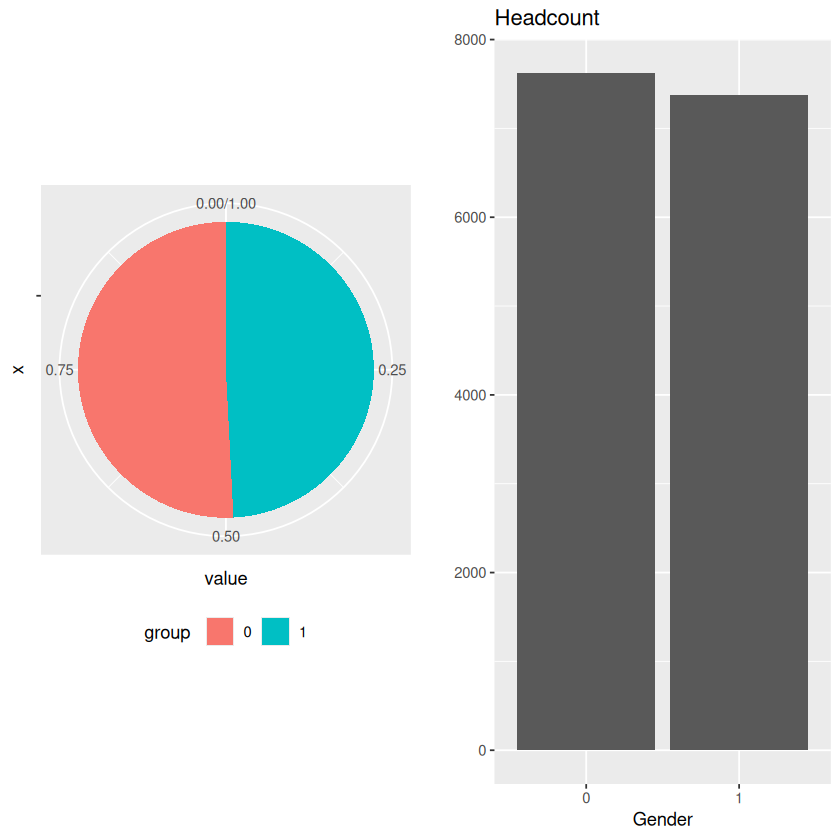

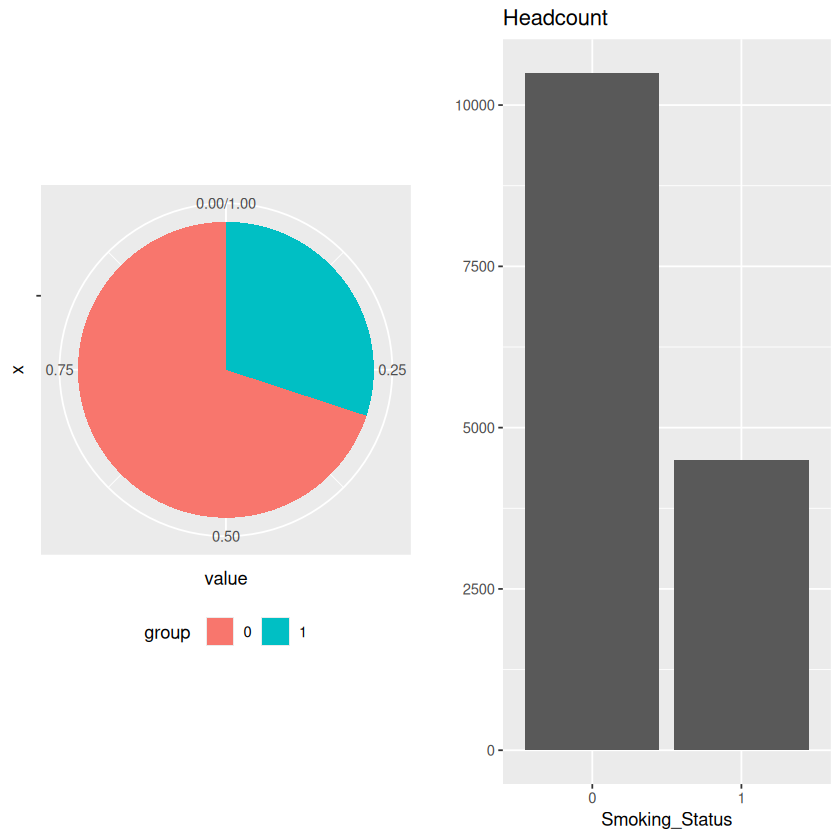

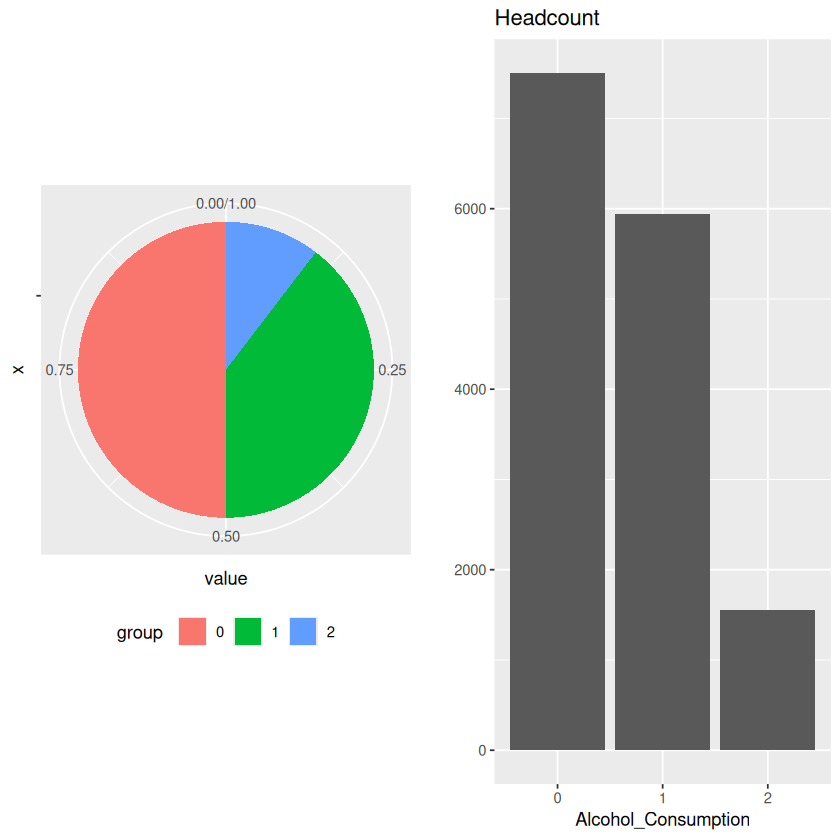

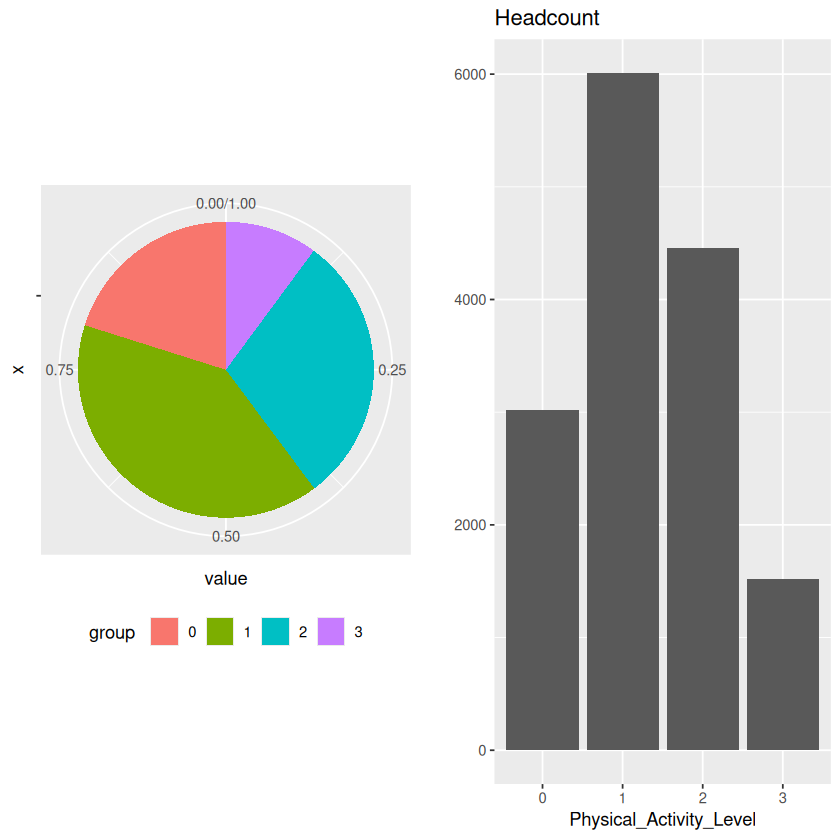

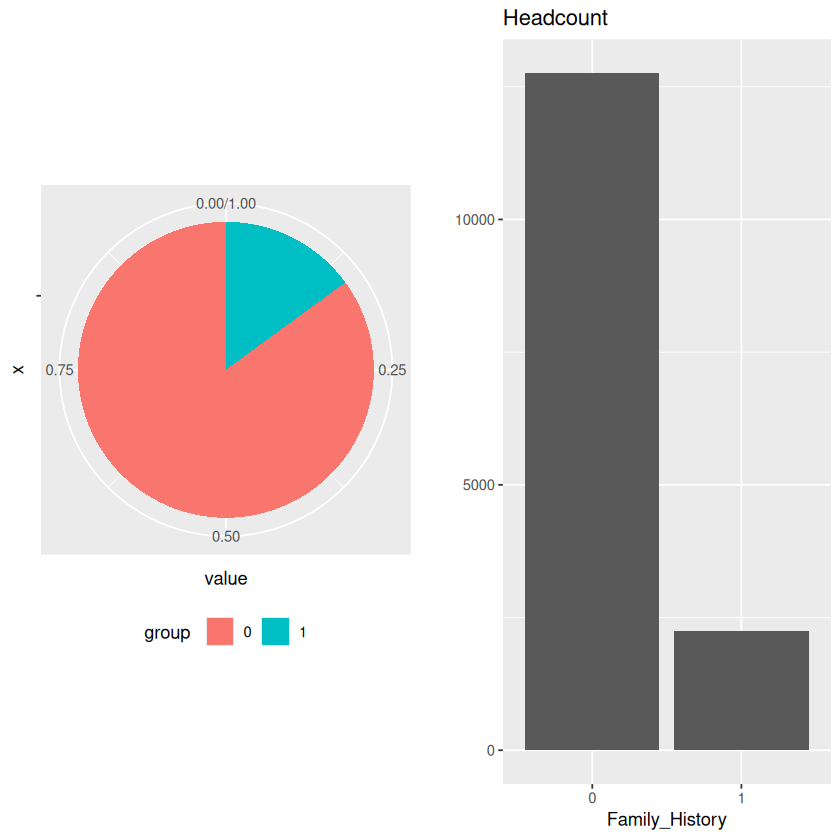

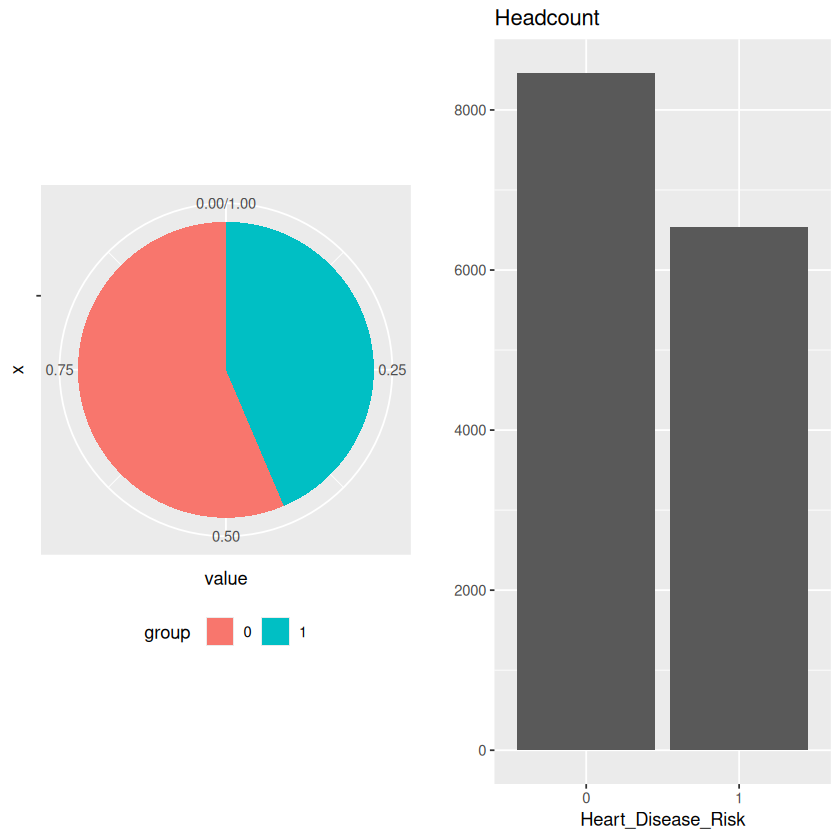

In [42]:
#Analyse des variables qualitatives

g1<-ggplot(df, aes(x=Gender))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
a<- data.frame(group = levels(df$Gender),
                 value = as.vector(table(df$Gender))/nrow(df))
g3<-ggplot(a, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g3,g1,ncol=2)


g4<-ggplot(df, aes(x=Smoking_Status))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
b<- data.frame(group = levels(df$Smoking_Status),
                 value = as.vector(table(df$Smoking_Status))/nrow(df))
g5<-ggplot(b, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g5,g4,ncol=2)


g6<-ggplot(df, aes(x=Alcohol_Consumption))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
c<- data.frame(group = levels(df$Alcohol_Consumption),
                 value = as.vector(table(df$Alcohol_Consumption))/nrow(df))
g7<-ggplot(c, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g7,g6,ncol=2)

g8<-ggplot(df, aes(x=Physical_Activity_Level))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
d<- data.frame(group = levels(df$Physical_Activity_Level),
                 value = as.vector(table(df$Physical_Activity_Level))/nrow(df))
g9<-ggplot(d, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g9,g8,ncol=2)

g10<-ggplot(df, aes(x=Family_History))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
e<- data.frame(group = levels(df$Family_History),
                 value = as.vector(table(df$Family_History))/nrow(df))
g11<-ggplot(e, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g11,g10,ncol=2)

g12<-ggplot(df, aes(x=Heart_Disease_Risk))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
f<- data.frame(group = levels(df$Heart_Disease_Risk),
                 value = as.vector(table(df$Heart_Disease_Risk))/nrow(df))
g13<-ggplot(f, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g13,g12,ncol=2)

Les diagrammes en barres et camemberts décrivent la répartition de chaque variable qualitative dans la population :
- Gender : répartition quasi équilibrée (~50% / 50%).
- Smoking_Status : environ 2/3 de non-fumeurs, 1/3 de fumeurs.
- Alcohol_Consumption : ~50% niveau 0 (aucune consommation), ~35% niveau 1 (modérée), ~15% niveau 2 (élevée).
- Physical_Activity_Level : ~20% niveau 0 (peu actif), ~40% niveau 1, ~30% niveau 2, ~10% niveau 3 (très actif).
- Family_History : ~80% sans antécédents familiaux, ~20% avec.
- Heart_Disease_Risk (variable cible) : ~56% de patients à faible risque (0) contre ~44% à risque élevé (1).

Le jeu de données est légèrement déséquilibré.

############# GENDER #############

   
       0    1
  0 4303 3319
  1 4157 3221

,0,1,Sum
0,4303,3319,7622
1,4157,3221,7378
Sum,8460,6540,15000



	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 0.014786, df = 1, p-value = 0.9032


   
            0         1
  0 0.5645500 0.4354500
  1 0.5634318 0.4365682
   
            0         1
  0 0.5086288 0.5074924
  1 0.4913712 0.4925076


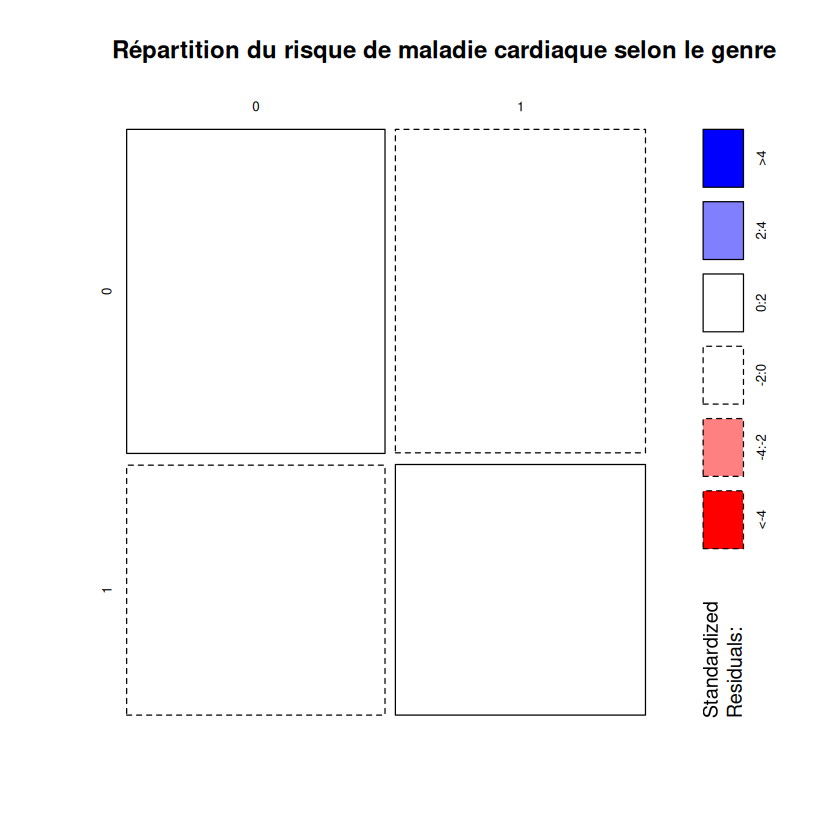


	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 0.014786, df = 1, p-value = 0.9032


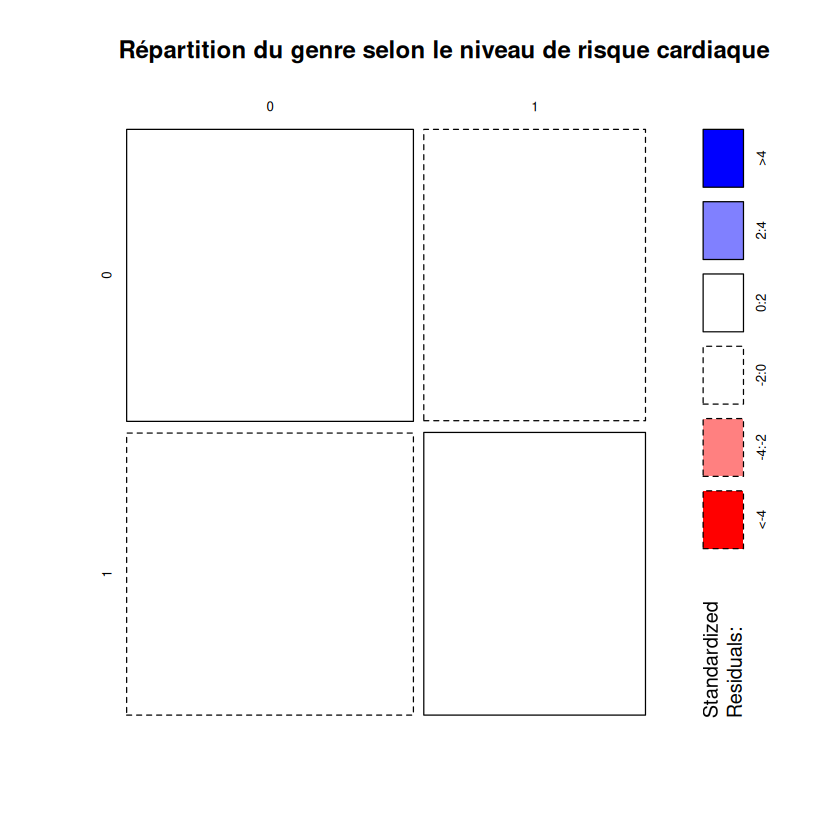

In [43]:
#Analyse des variables qualitatives (par rapport a Heart_Disease_Risk

###### GENDER ######
par(mfrow=c(1,1))
cat("############# GENDER #############")
contingency_table <- table(df$Gender, df$Heart_Disease_Risk)
contingency_table
contingency_table_margins <- addmargins(contingency_table)
contingency_table_margins
chisq.test(contingency_table)

# Table de contingence
contingency_table <- table(df$Gender, df$Heart_Disease_Risk)

# Calcul des profils-lignes (somme de chaque ligne = 1)
profile_rows <- prop.table(contingency_table, margin = 1)
print(profile_rows)

mosaicplot(contingency_table, shade = TRUE, main = "Répartition du risque de maladie cardiaque selon le genre")

# Calcul des profils-colonnes (somme de chaque colonne = 1)
profile_cols <- prop.table(contingency_table, margin = 2)
print(profile_cols)

mosaicplot(t(contingency_table), shade = TRUE, main = "Répartition du genre selon le niveau de risque cardiaque")

chisq.test(contingency_table)

Gender : Le test du chi² donne X² = 0.015, p-valeur = 0.90. On ne rejette pas l'indépendance : le genre n'a aucun effet significatif sur le risque cardiaque dans ce jeu de données.


############# SMOKING_STATUS #############

   
       0    1
  0 7121 3374
  1 1339 3166

,0,1,Sum
0,7121,3374,10495
1,1339,3166,4505
Sum,8460,6540,15000



	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 1861.9, df = 1, p-value < 2.2e-16


   
            0         1
  0 0.6785136 0.3214864
  1 0.2972253 0.7027747
   
            0         1
  0 0.8417258 0.5159021
  1 0.1582742 0.4840979


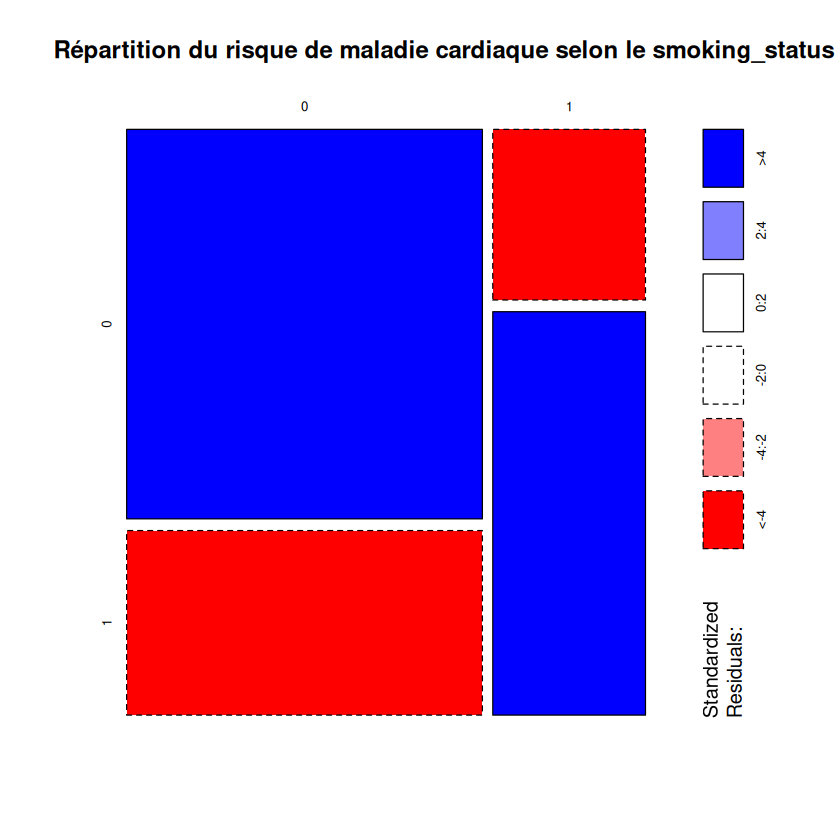


	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 1861.9, df = 1, p-value < 2.2e-16


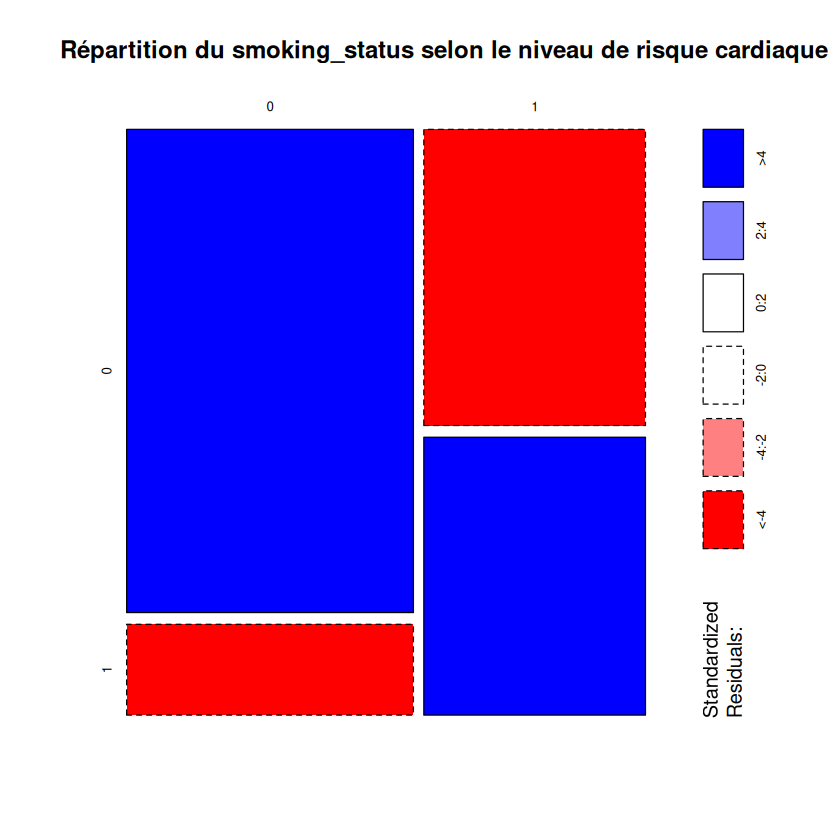

In [44]:
###### SMOKING_STATUS ######
par(mfrow=c(1,1))
cat("\n############# SMOKING_STATUS #############")
contingency_table <- table(df$Smoking_Status, df$Heart_Disease_Risk)
contingency_table
contingency_table_margins <- addmargins(contingency_table)
contingency_table_margins
chisq.test(contingency_table)

# Table de contingence
contingency_table <- table(df$Smoking_Status, df$Heart_Disease_Risk)

# Calcul des profils-lignes (somme de chaque ligne = 1)
profile_rows <- prop.table(contingency_table, margin = 1)
print(profile_rows)

mosaicplot(contingency_table, shade = TRUE, main = "Répartition du risque de maladie cardiaque selon le smoking_status")

# Calcul des profils-colonnes (somme de chaque colonne = 1)
profile_cols <- prop.table(contingency_table, margin = 2)
print(profile_cols)

mosaicplot(t(contingency_table), shade = TRUE, main = "Répartition du smoking_status selon le niveau de risque cardiaque")

chisq.test(contingency_table)

Smoking_Status : Le test du chi² donne X² = 1861.9, p-valeur < 2.2e-16. La liaison est très fortement significative. Les fumeurs ont un risque cardiaque élevé dans ~70% des cas contre ~32% pour les non-fumeurs. C'est la variable qualitative la plus discriminante.


############# ALCOHOL_CONSUMPTION #############

   
       0    1
  0 4202 3300
  1 3384 2555
  2  874  685

,0,1,Sum
0,4202,3300,7502
1,3384,2555,5939
2,874,685,1559
Sum,8460,6540,15000



	Pearson's Chi-squared test

data:  contingency_table
X-squared = 1.343, df = 2, p-value = 0.5109


   
            0         1
  0 0.5601173 0.4398827
  1 0.5697929 0.4302071
  2 0.5606158 0.4393842
   
            0         1
  0 0.4966903 0.5045872
  1 0.4000000 0.3906728
  2 0.1033097 0.1047401


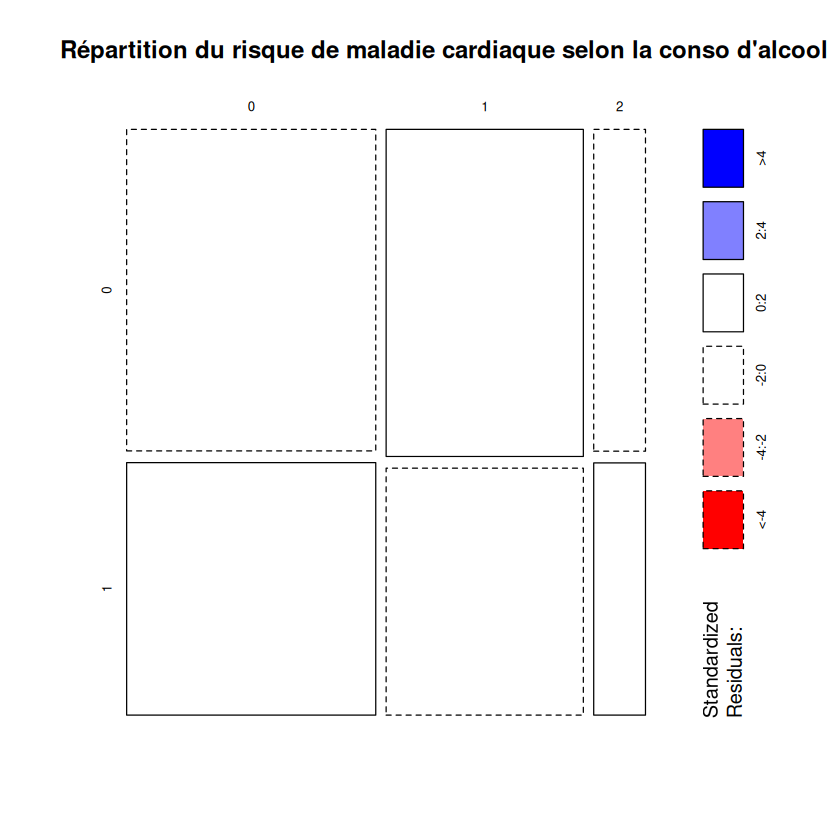


	Pearson's Chi-squared test

data:  contingency_table
X-squared = 1.343, df = 2, p-value = 0.5109


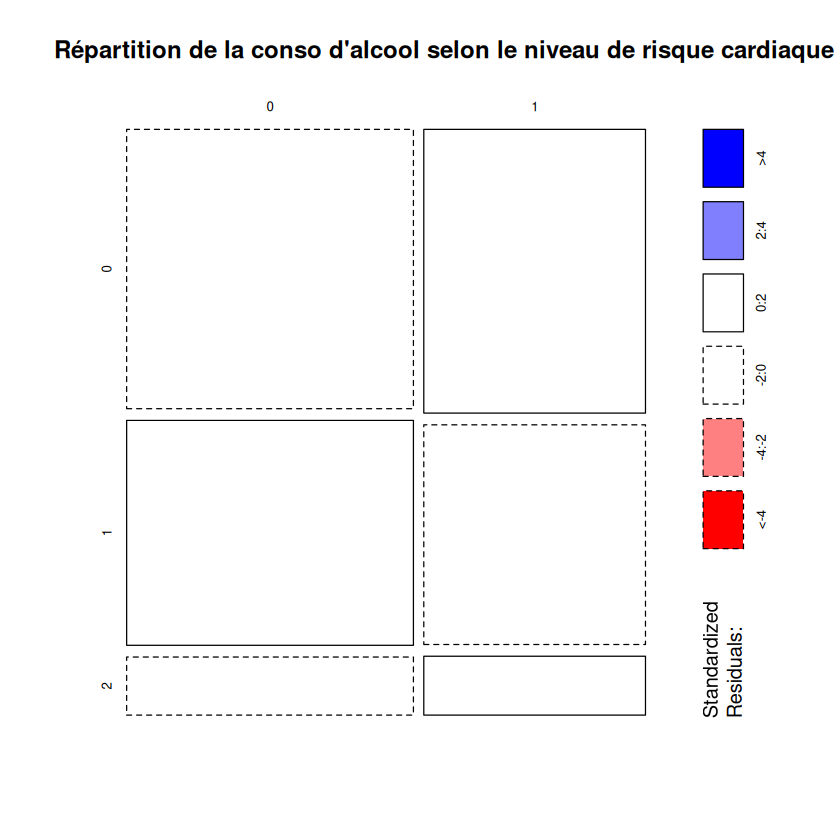

In [45]:
###### ALCOHOL_CONSUMPTION ######
par(mfrow=c(1,1))
cat("\n############# ALCOHOL_CONSUMPTION #############")
contingency_table <- table(df$Alcohol_Consumption, df$Heart_Disease_Risk)
contingency_table
contingency_table_margins <- addmargins(contingency_table)
contingency_table_margins
chisq.test(contingency_table)

# Table de contingence
contingency_table <- table(df$Alcohol_Consumption, df$Heart_Disease_Risk)

# Calcul des profils-lignes (somme de chaque ligne = 1)
profile_rows <- prop.table(contingency_table, margin = 1)
print(profile_rows)

mosaicplot(contingency_table, shade = TRUE, main = "Répartition du risque de maladie cardiaque selon la conso d'alcool")

# Calcul des profils-colonnes (somme de chaque colonne = 1)
profile_cols <- prop.table(contingency_table, margin = 2)
print(profile_cols)

mosaicplot(t(contingency_table), shade = TRUE, main = "Répartition de la conso d'alcool selon le niveau de risque cardiaque")

chisq.test(contingency_table)

Alcohol_Consumption : Le test du chi² donne X² = 1.34, p-valeur = 0.51. On ne rejette pas l'indépendance : la consommation d'alcool n'est pas associée au risque cardiaque dans ce jeu de données.


############# PHYSICAL_ACTIVITY_LEVEL #############

   
       0    1
  0 1334 1686
  1 3244 2765
  2 2819 1634
  3 1063  455

,0,1,Sum
0,1334,1686,3020
1,3244,2765,6009
2,2819,1634,4453
3,1063,455,1518
Sum,8460,6540,15000



	Pearson's Chi-squared test

data:  contingency_table
X-squared = 398.85, df = 3, p-value < 2.2e-16


   
            0         1
  0 0.4417219 0.5582781
  1 0.5398569 0.4601431
  2 0.6330564 0.3669436
  3 0.7002635 0.2997365
   
             0          1
  0 0.15768322 0.25779817
  1 0.38345154 0.42278287
  2 0.33321513 0.24984709
  3 0.12565012 0.06957187


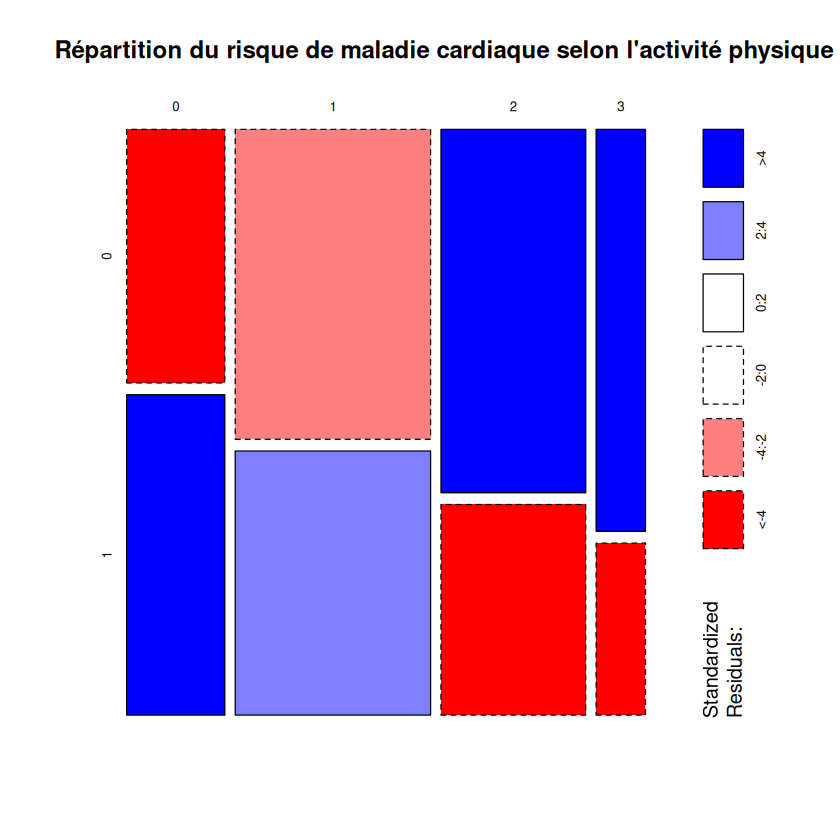


	Pearson's Chi-squared test

data:  contingency_table
X-squared = 398.85, df = 3, p-value < 2.2e-16


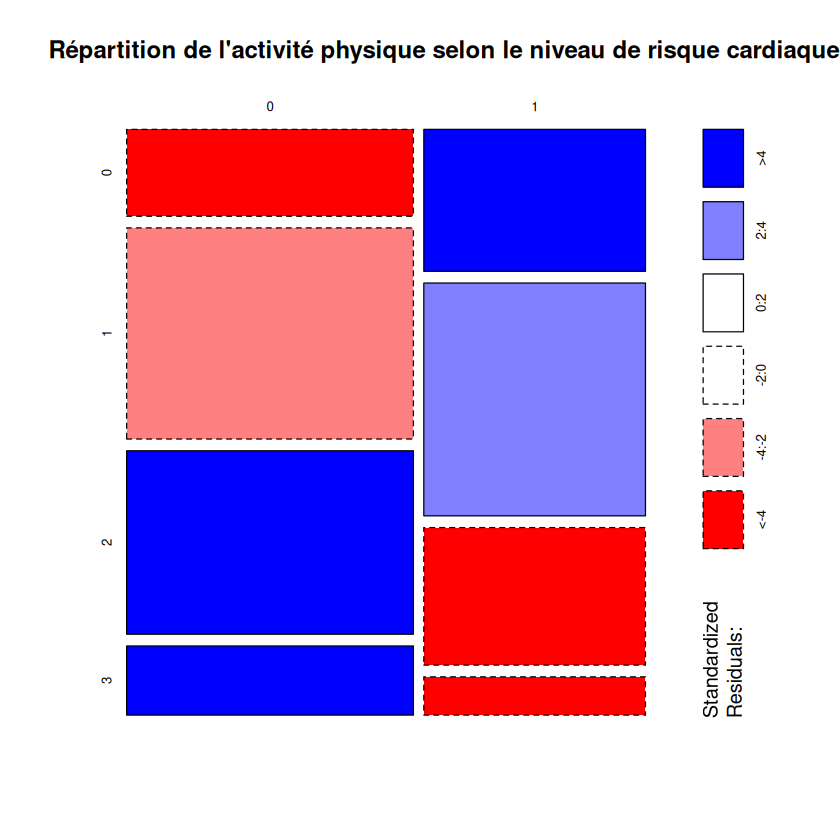

In [46]:
###### PHYSICAL_ACTIVITY_LEVEL ######
par(mfrow=c(1,1))
cat("\n############# PHYSICAL_ACTIVITY_LEVEL #############")
contingency_table <- table(df$Physical_Activity_Level, df$Heart_Disease_Risk)
contingency_table
contingency_table_margins <- addmargins(contingency_table)
contingency_table_margins
chisq.test(contingency_table)

# Table de contingence
contingency_table <- table(df$Physical_Activity_Level, df$Heart_Disease_Risk)

# Calcul des profils-lignes (somme de chaque ligne = 1)
profile_rows <- prop.table(contingency_table, margin = 1)
print(profile_rows)

mosaicplot(contingency_table, shade = TRUE, main = "Répartition du risque de maladie cardiaque selon l'activité physique")

# Calcul des profils-colonnes (somme de chaque colonne = 1)
profile_cols <- prop.table(contingency_table, margin = 2)
print(profile_cols)

mosaicplot(t(contingency_table), shade = TRUE, main = "Répartition de l'activité physique selon le niveau de risque cardiaque")

chisq.test(contingency_table)

#Moins on fait de sport, plus on a de risques.

Physical_Activity_Level : Le test du chi² donne X² = 398.9, p-valeur < 2.2e-16. La liaison est très fortement significative. On observe un gradient clair : plus le niveau d'activité physique est élevé, plus le risque cardiaque diminue. Les patients sédentaires (niveau 0) ont un risque élevé dans ~56% des cas, contre seulement ~30% pour les plus actifs (niveau 3).


############# FAMILY_HISTORY #############

   
       0    1
  0 7729 5028
  1  731 1512

,0,1,Sum
0,7729,5028,12757
1,731,1512,2243
Sum,8460,6540,15000



	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 606.88, df = 1, p-value < 2.2e-16


   
            0         1
  0 0.6058634 0.3941366
  1 0.3259028 0.6740972
   
             0          1
  0 0.91359338 0.76880734
  1 0.08640662 0.23119266


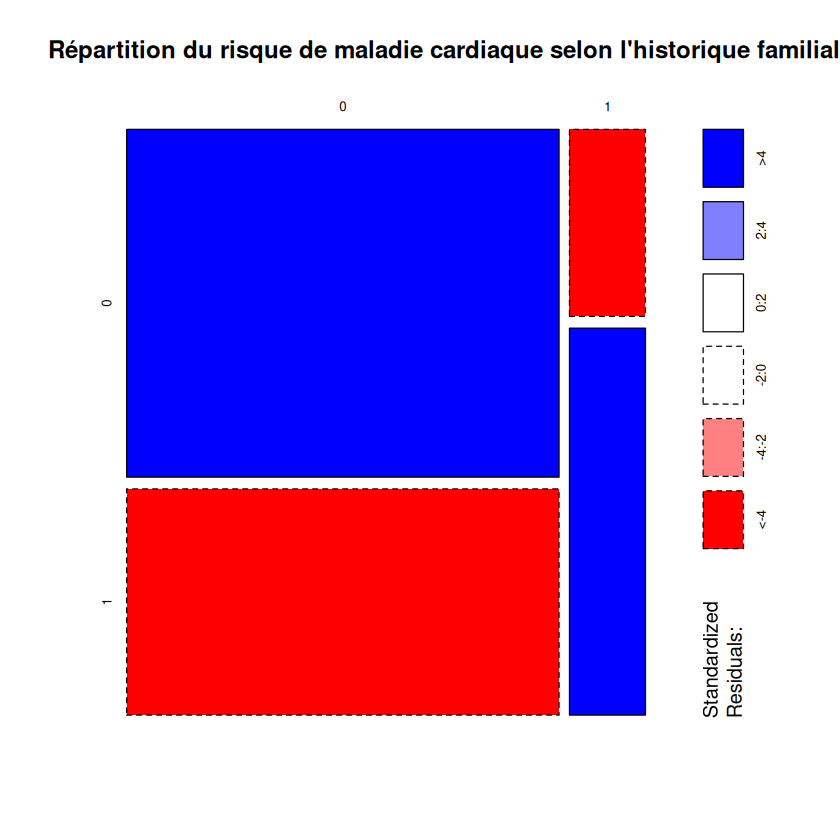


	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 606.88, df = 1, p-value < 2.2e-16


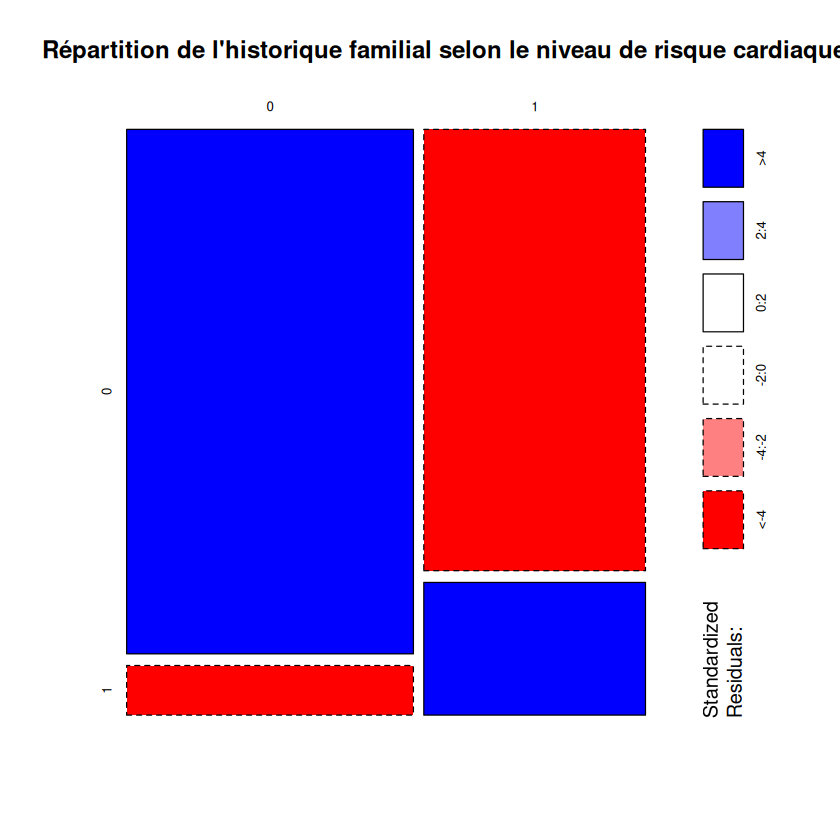

In [47]:
###### FAMILY_HISTORY ######
par(mfrow=c(1,1))
cat("\n############# FAMILY_HISTORY #############")
contingency_table <- table(df$Family_History, df$Heart_Disease_Risk)
contingency_table
contingency_table_margins <- addmargins(contingency_table)
contingency_table_margins
chisq.test(contingency_table)

# Table de contingence
contingency_table <- table(df$Family_History, df$Heart_Disease_Risk)

# Calcul des profils-lignes (somme de chaque ligne = 1)
profile_rows <- prop.table(contingency_table, margin = 1)
print(profile_rows)

mosaicplot(contingency_table, shade = TRUE, main = "Répartition du risque de maladie cardiaque selon l'historique familial")

# Calcul des profils-colonnes (somme de chaque colonne = 1)
profile_cols <- prop.table(contingency_table, margin = 2)
print(profile_cols)

mosaicplot(t(contingency_table), shade = TRUE, main = "Répartition de l'historique familial selon le niveau de risque cardiaque")

chisq.test(contingency_table)

Family_History : Le test du chi² donne X² = 606.9, p-valeur < 2.2e-16. La liaison est très fortement significative. Les patients avec des antécédents familiaux de maladie cardiaque ont un risque élevé dans ~67% des cas, contre ~39% pour ceux sans antécédents. L'hérédité constitue donc un facteur de risque important.

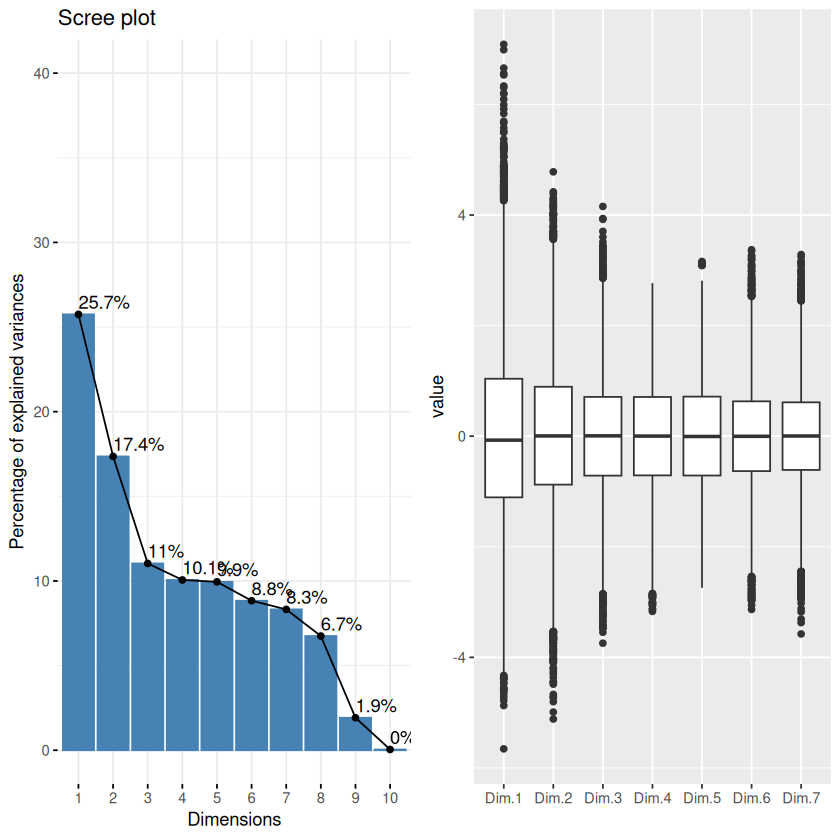

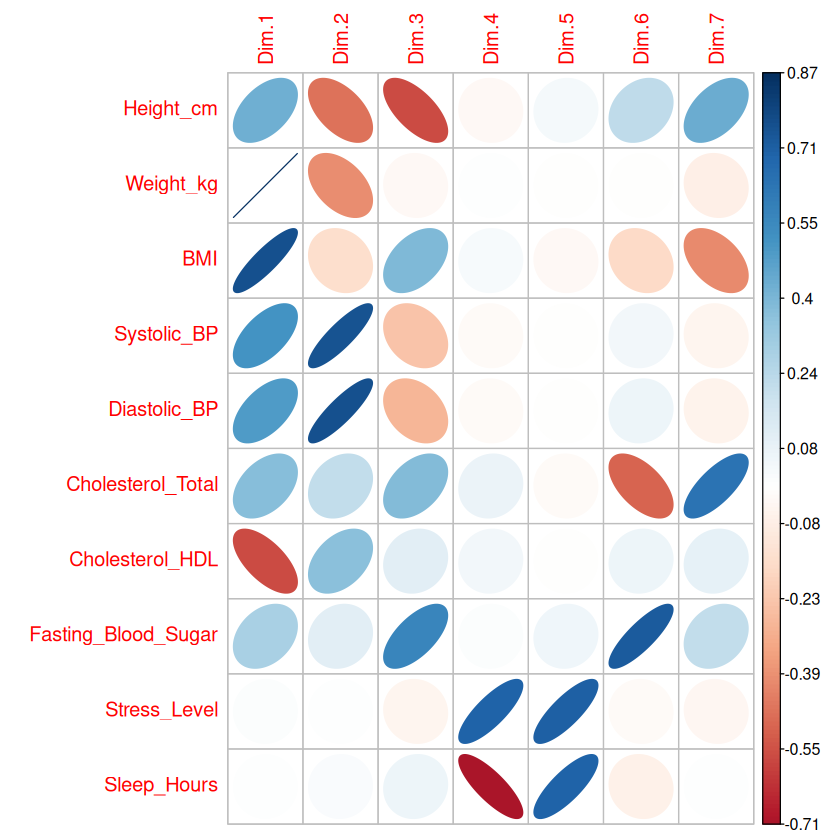

In [48]:
### ACP ####

# ACP réduite
acp <- PCA(df[,c(1, 3:11, 16:17)], scale.unit = TRUE,
           graph = FALSE, quali.sup = 1, quanti.sup = 8, ncp = 7)
# Décroissance des valeurs propres
g1<-fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))
g2<-ggplot(melt(acp$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)
# 
corrplot(acp$var$cor, is.corr=FALSE,method="ellipse")

La matrice des corrélations aux composantes principales (corrplot sur les coordonnées) permet d'identifier quelles variables sont bien représentées dans chaque dimension :
- **Dim 1** est principalement associée à Weight_kg (très fortement), BMI, Height_cm, Systolic_BP, Diastolic_BP, Cholesterol_Total (direction opposée à Cholesterol_HDL) et dans une moindre mesure Fasting_Blood_Sugar.
- **Dim 2** est liée à Systolic_BP, Diastolic_BP, Cholesterol_Total, Cholesterol_HDL (direction opposée à Weight_kg, BMI et Height_cm).
- **Dim 3** oppose  Systolic_BP/Diastolic_BP  à  Cholesterol_Total/Cholesterol_LDL .
- Stress_level et Sleep_hours n'apparaissent significativement qu'en **dimensions 4 et 5**, ce qui confirme qu'elles portent une information indépendante des autres variables quantitatives.
- Fasting_Blood_Sugar est principalement représenté en **dimension 6**, opposé au Cholesterol_Total.

L'éboulis des valeurs propres montre que la variance est relativement bien répartie entre les dimensions : Dim 1 (25.7%), Dim 2 (17.4%), Dim 3 (11%), Dim 4 (10.1%), Dim 5 (9.9%). Aucune dimension ne domine nettement, ce qui traduit une structure multivariée complexe sans axe principal très dominant. Nous concentrerons notre interprétation sur les trois premières dimensions, qui expliquent ensemble ~54% de la variance totale.

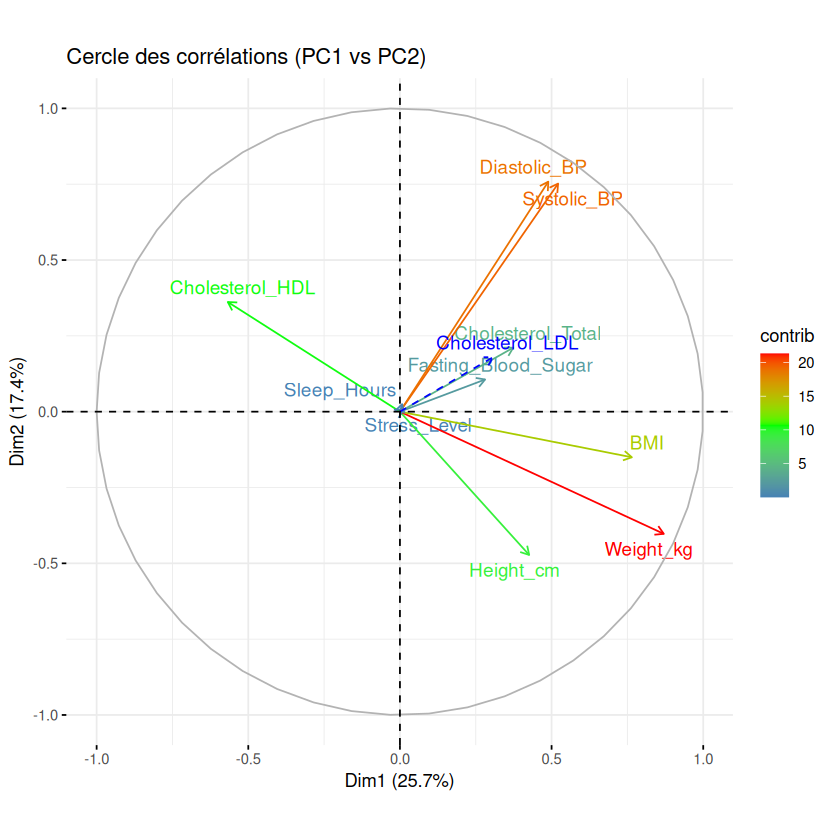

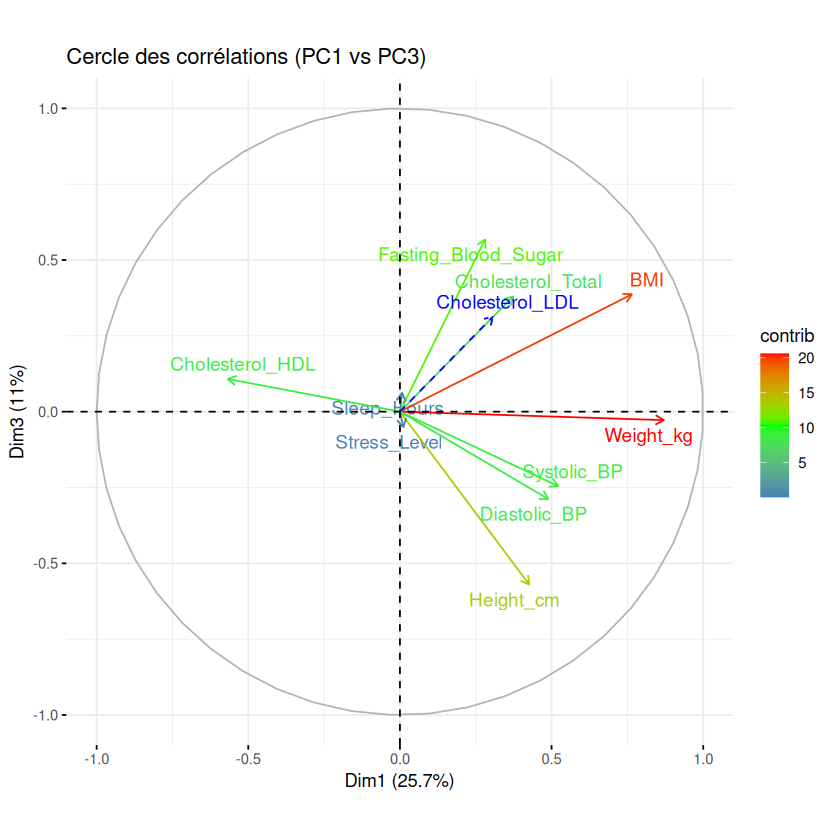

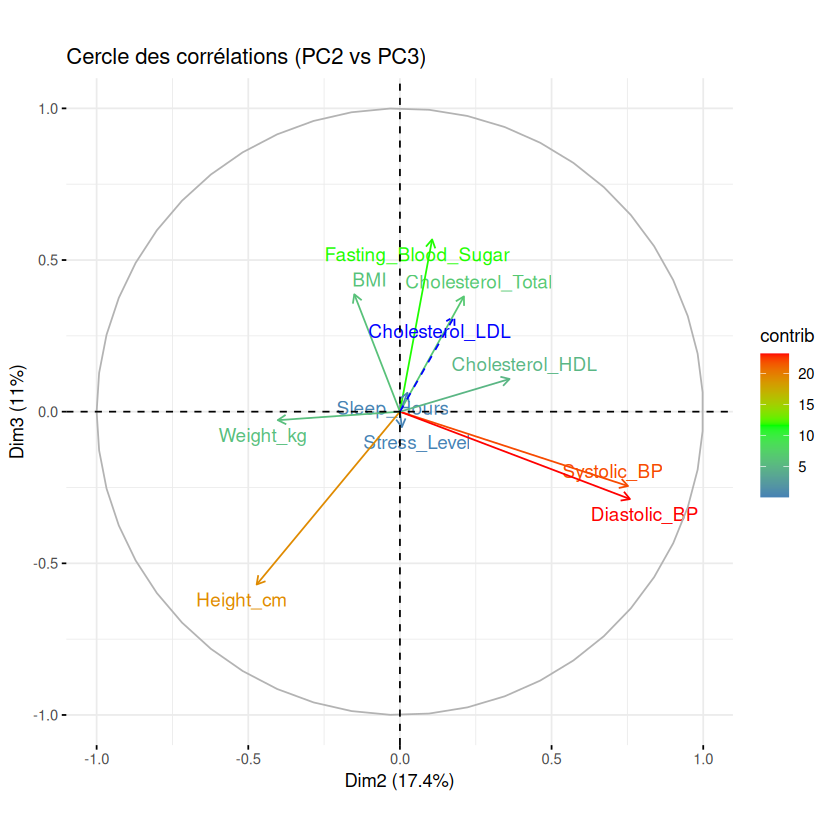

In [49]:
# Cercles des corrélations
fviz_pca_var(acp,
             col.var="contrib",
             gradient.cols=c("steelblue","green","red"),
             repel=TRUE,
             title="Cercle des corrélations (PC1 vs PC2)")

fviz_pca_var(acp,
             col.var="contrib",
             gradient.cols=c("steelblue","green","red"),
             repel=TRUE,
             title="Cercle des corrélations (PC1 vs PC3)",axes=c(1,3))

fviz_pca_var(acp,
             col.var="contrib",
             gradient.cols=c("steelblue","green","red"),
             repel=TRUE,
             title="Cercle des corrélations (PC2 vs PC3)",axes=c(2,3))

**Cercle des corrélations PC1-PC2** : La Dim 1 (25.7%, axe horizontal) structure les variables de corpulence et de profil cardiovasculaire à droite : Weight_kg contribu le plus (en rouge), suivis de Systolic_BP, Diastolic_BP, BMI, Height_cm. Fasting_Blood_Sugar, Cholesterol_Total et Cholesterol_LDL pointent également vers la droite mais avec une contribution plus faible. Cholesterol_HDL est projeté à gauche, dans la direction opposée. La Dim 2 (17.4%, axe vertical) sépare vers le haut Systolic_BP et Diastolic_BP des variables de corpulence Weight_kg et Height_cm situées en bas (et dans une moindre mesure BMI). Fasting_Blood_Sugar, Stress_Level et Sleep_Hours sont proches du centre et quasi non représentés dans ce plan.

**Cercle des corrélations PC1-PC3** : La Dim 3 (11%) oppose en haut Fasting_Blood_Sugar, Cholesterol_Total et BMI à Diastolic_BP, Systolic_BP et Height_cm situés en bas. Cholesterol_LDL (en bleu, variable supplémentaire) se projette proche de Cholesterol_Total, confirmant leur forte colinéarité.

**Cercle des corrélations PC2-PC3** : Ce plan confirme la dissociation entre pression artérielle (Systolic_BP, Diastolic_BP en bas à droite) et profil lipidique (Cholesterol_Total, Cholesterol_LDL en haut). Height_cm se distingue nettement en bas à gauche, suggérant qu'elle porte une information spécifique indépendante des autres variables de corpulence dans ce plan. Cholesterol_HDL se projette ne nouveau proche de Cholesterol_Total.

Cholesterol_LDL (variable supplémentaire, en bleu foncé) se projette très près de Cholesterol_Total dans le biplot, confirmant leur forte colinéarité déjà observée dans la matrice de corrélations.

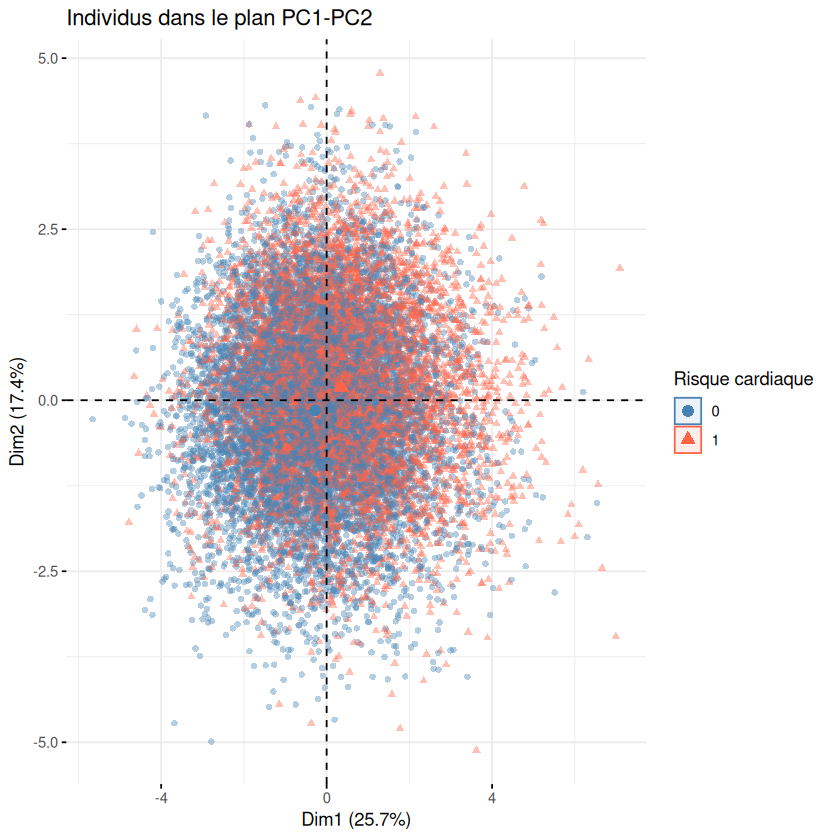

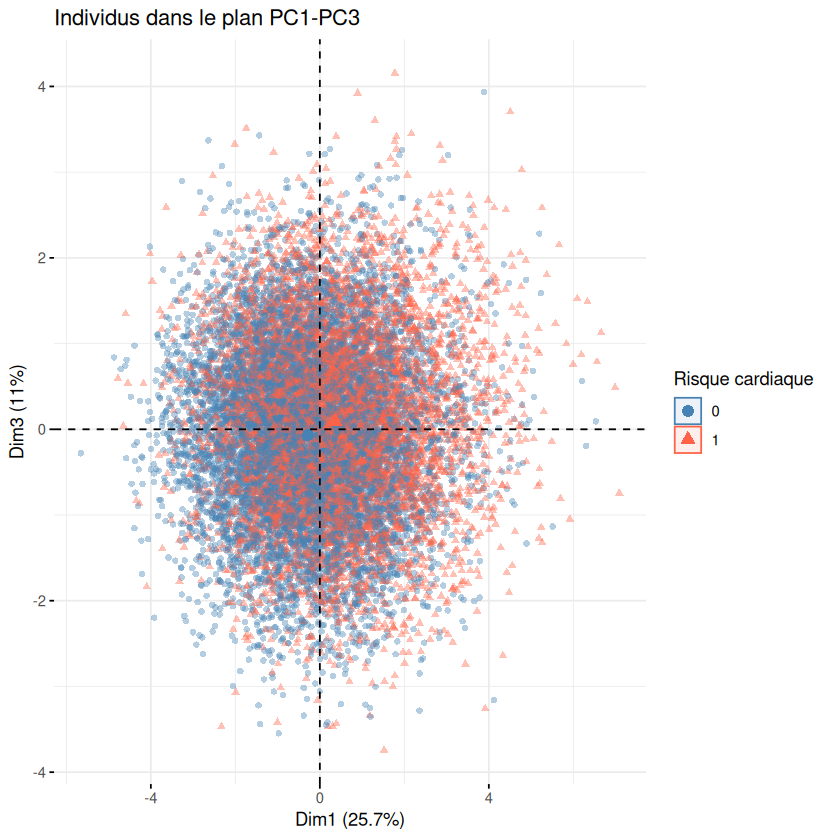

In [50]:
# Biplot des individus coloré par Heart_Disease_Risk
fviz_pca_ind(acp,
             geom.ind = "point",
             col.ind = df$Heart_Disease_Risk,
             palette = c("steelblue", "tomato"),
             addEllipses = TRUE,
             ellipse.type = "confidence",
             legend.title = "Risque cardiaque",
             title = "Individus dans le plan PC1-PC2",
             alpha.ind = 0.4)

fviz_pca_ind(acp,
             axes = c(1, 3),
             geom.ind = "point",
             col.ind = df$Heart_Disease_Risk,
             palette = c("steelblue", "tomato"),
             addEllipses = TRUE,
             ellipse.type = "confidence",
             legend.title = "Risque cardiaque",
             title = "Individus dans le plan PC1-PC3",
             alpha.ind = 0.4)



Les biplots des individus colorés par Heart_Disease_Risk montrent que les deux nuages (bleu = risque faible, rouge = risque élevé) se superposent quasi-totalement, aussi bien dans le plan PC1-PC2 que PC1-PC3. Les ellipses de confiance se chevauchent largement, confirmant que les variables quantitatives seules ne permettent pas de discriminer les patients à risque cardiaque élevé dans les premiers plans de l'ACP.

Ce résultat est cohérent avec les boxplots : les différences de moyennes entre les deux groupes existent mais sont trop faibles pour structurer la variance globale. On confirme ainsi que le signal prédictif principal est porté par les variables qualitatives, en particulier Smoking_Status, Physical_Activity_Level et Family_History, qui avaient montré des liaisons très significatives (chi² avec p < 2.2e-16).

## 3. Conclusion de l'analyse exploratoire

Cette analyse exploratoire met en évidence plusieurs résultats structurants pour la suite de la modélisation :

**Variables les plus discriminantes pour Heart_Disease_Risk :**
- Parmi les variables qualitatives : Smoking_Status, Physical_Activity_Level et Family_History présentent des liaisons très fortement significatives (chi² p < 2.2e-16). À l'inverse, Alcohol_Consumption et Gender n'ont pas d'effet significatif.
- Parmi les variables quantitatives : Age, BMI, Systolic_BP, Diastolic_BP, Stress_Level et Sleep_Hours montrent des différences notables entre les deux groupes de risque. Height_cm semble la seule variable quantitative sans effet.

**Structure des variables quantitatives (ACP) :**
- La variance est répartie sur de nombreuses dimensions, sans axe dominant, ce qui reflète la multicolinéarité entre plusieurs groupes de variables (corpulence, pression artérielle, profil lipidique).
- Stress_Level et Sleep_Hours portent une information indépendante, captée uniquement en dimensions 4 et 5.
- L'ACP ne discrimine pas Heart_Disease_Risk, ce qui confirme que les variables qualitatives portent l'essentiel du signal prédictif.

**Pour Cholesterol_LDL :** cette variable est fortement colinéaire avec Cholesterol_Total et dans une moindre mesure, corrélée positivement avec Age. Ces corrélations suggèrent que ces variables pourraient jouer un rôle dans sa prédiction, mais c'est la phase de modélisation qui permettra de le confirmer.